# Handoffs Pattern (핸드오프 패턴: 한 에이전트가 세 전문가 역할을 순서대로 수행)"

**핸드오프 패턴(Handoffs Pattern)** 은 단일 에이전트가 여러 상태(state)를 거치며 작업을 수행하는 패턴입니다.
각 상태마다 다른 프롬프트와 도구를 사용하여, 복잡한 워크플로우를 단일 에이전트로 구현할 수 있습니다.

이 튜토리얼에서는 고객 지원(Customer Support) 시나리오를 구현합니다:
- 보증 상태 확인 → 이슈 분류 → 해결책 제공

**참고**: [LangChain 공식 문서 - Handoffs Customer Support](https://docs.langchain.com/oss/python/langchain/multi-agent/handoffs-customer-support)

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [2]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-5-mini", model_provider="openai")

## 1. 상태 스키마 정의

워크플로우의 상태를 정의합니다. 각 단계와 수집된 정보를 저장합니다.
```
Agent Workflow  
   ↓  
State(State 객체)  
   ↓
각 Step 노드가 State 읽고 수정
   ↓
그래프가 다음 Step 결정
```

In [3]:
from langchain.agents import AgentState
from typing_extensions import NotRequired
from typing import Literal

# 가능한 워크플로우 단계
SupportStep = Literal["warranty_collector", "issue_classifier", "resolution_specialist"]  #상태 값 제한 패턴

# 보증 상태
WarrantyStatus = Literal["in_warranty", "out_of_warranty"]

# 이슈 유형
IssueType = Literal["hardware", "software"]

class SupportState(AgentState):
    """고객 지원 워크플로우 상태"""
    current_step: NotRequired[SupportStep]  # 워크플로우 현재 단계
    warranty_status: NotRequired[WarrantyStatus]  # 보증 상태
    issue_type: NotRequired[IssueType]  # 이슈 유형

## 2. 상태 관리 도구 정의

각 단계에서 상태를 업데이트하는 도구를 정의합니다.

In [4]:
from langchain.tools import tool, ToolRuntime
from langchain.messages import ToolMessage
from langgraph.types import Command


@tool
def record_warranty_status(
    status: Literal["in_warranty", "out_of_warranty"],
    runtime: ToolRuntime[None, SupportState],
) -> Command:
    """
    고객의 보증 상태를 기록하고 다음 단계(이슈 분류 단계)로 전환하는 Tool
    
    역할:
        1. 고객의 제품 보증 상태 저장
        2. 상태(State)에 메시지 기록
        3. 워크플로우를 다음 단계(issue_classifier)로 이동
    
    Args:
        status:
            고객 제품 보증 상태
            - "in_warranty" : 보증 기간 내
            - "out_of_warranty" : 보증 기간 외
            
        runtime:
            Tool 실행 환경 정보
            - tool_call_id : Tool 호출 추적 ID
            - 현재 Agent 실행 Context 접근 가능
            
    Returns:
        Command 객체
        → LangGraph State 업데이트 및 다음 단계 제어
    """
    
    return Command(
        update={
            # Tool 실행 결과를 메시지 히스토리에 추가
            "messages": [
                ToolMessage(
                    content=f"Warranty status recorded as: {status}",
                    # Tool 호출과 메시지를 연결하기 위한 ID
                    tool_call_id=runtime.tool_call_id,
                )
            ],
            
            # 고객 보증 상태를 State 에 저장
            "warranty_status": status,
            # 다음 워크플로우 단계 지정
            "current_step": "issue_classifier",
        }
    )


@tool
def record_issue_type(
    issue_type: Literal["hardware", "software"],
    runtime: ToolRuntime[None, SupportState],  #입력 컨텍스트는 없고(None) Agent State 타입은 SupportState를 사용
) -> Command:
    """
    고객 문제 유형을 기록하고 해결 단계로 전환하는 Tool
    
    역할:
        1. 문제 유형 저장
        2. 상태(State)에 메시지 기록
        3. 워크플로우를 해결 전문가 단계로 이동
    
    Args:
        issue_type:
            문제 유형
            - "hardware" : 하드웨어 문제
            - "software" : 소프트웨어 문제
            
        runtime:
            Tool 실행 런타임 정보
            - tool_call_id 포함
            
    Returns:
        Command 객체
        → State 업데이트 + 다음 단계 이동
    """
    
    return Command(
        update={
            # Tool 실행 결과 메시지 기록
            "messages": [
                ToolMessage(
                    content=f"Issue type recorded as: {issue_type}",
                    tool_call_id=runtime.tool_call_id,
                )
            ],
            
            # 문제 유형 상태 저장
            "issue_type": issue_type,
            # 다음 단계 설정
            "current_step": "resolution_specialist",
        }
    )


@tool
def escalate_to_human(reason: str) -> str:
    """
    고객 문제를 사람이 직접 처리하도록 에스컬레이션하는 Tool
    
    실제 시스템에서는:
        - 지원 티켓 생성
        - 담당자 알림 전송
        - CRM 시스템 등록
        등의 동작이 수행될 수 있음
    
    Args:
        reason:
            사람이 처리해야 하는 이유
            
    Returns:
        에스컬레이션 결과 메시지
    """
    
    # 실제 서비스에서는 외부 시스템 연동 로직이 들어갈 위치
    return f"Escalating to human support. Reason: {reason}"


@tool
def provide_solution(solution: str) -> str:
    """
    고객 문제 해결 방안을 제공하는 Tool
    
    역할:
        - 고객에게 해결 방법 안내
        - 자동 응답 시스템에서 해결 메시지 생성
        
    Args:
        solution:
            고객에게 전달할 해결 방안
            
    Returns:
        해결 안내 메시지
    """
    
    return f"Solution provided: {solution}"

## 3. 단계별 프롬프트 정의

각 단계마다 다른 시스템 프롬프트를 사용합니다.

In [5]:
# 보증 수집 단계 프롬프트
WARRANTY_COLLECTOR_PROMPT = """당신은 고객 지원 에이전트입니다.

현재 단계: 보증 확인

이 단계에서 해야 할 일:
1. 고객에게 친절하게 인사하세요
2. 기기가 보증 기간 내인지 물어보세요
3. record_warranty_status 도구를 사용하여 응답을 기록하고 다음 단계로 이동하세요

대화적이고 친근하게 대화하세요. 한 번에 여러 질문을 하지 마세요."""

# 이슈 분류 단계 프롬프트
ISSUE_CLASSIFIER_PROMPT = """당신은 고객 지원 에이전트입니다.

현재 단계: 이슈 분류
고객 정보: 보증 상태는 {warranty_status}입니다

이 단계에서 해야 할 일:
1. 고객에게 문제를 설명해달라고 요청하세요
2. 하드웨어 문제(물리적 손상, 부품 고장)인지 소프트웨어 문제(앱 충돌, 성능 저하)인지 판단하세요
3. record_issue_type 도구를 사용하여 분류를 기록하고 다음 단계로 이동하세요

불명확한 경우 분류하기 전에 명확히 질문하세요."""

# 해결책 제공 단계 프롬프트
RESOLUTION_SPECIALIST_PROMPT = """당신은 고객 지원 에이전트입니다.

현재 단계: 해결책 제공
고객 정보: 보증 상태는 {warranty_status}, 이슈 유형은 {issue_type}입니다

이 단계에서 해야 할 일:
1. 소프트웨어 문제인 경우: provide_solution을 사용하여 문제 해결 단계를 제공하세요
2. 하드웨어 문제인 경우:
   - 보증 기간 내: provide_solution을 사용하여 보증 수리 프로세스를 설명하세요
   - 보증 기간 만료: escalate_to_human을 사용하여 유료 수리 옵션을 위해 인간 지원으로 에스컬레이션하세요

구체적이고 도움이 되는 해결책을 제공하세요."""

## 4. 단계별 설정(STEP_CONFIG) 및 wrap_model_call 미들웨어

최신 문서: 현재 상태(current_step)에 따라 프롬프트와 도구를 request.override로 주입합니다. 
```
"warranty_collector":     {"requires": []},                                  # 첫 단계 — 조건 없음
"issue_classifier":       {"requires": ["warranty_status"]},                 # 보증 상태가 기록돼 있어야 진입
"resolution_specialist":  {"requires": ["warranty_status", "issue_type"]},   # 둘 다 있어야 진입
```

In [13]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable

# ------------------------------------------------------------
# 단계별 Agent 설정 정보
# ------------------------------------------------------------
# 각 워크플로우 단계마다
#   1. 사용할 시스템 프롬프트
#   2. 허용할 Tool 목록
#   3. 해당 단계에 진입하기 위한 필수 상태(State)
# 를 정의하는 설정 테이블

STEP_CONFIG = {

    # -----------------------------
    # 보증 상태 수집 단계
    # -----------------------------
    "warranty_collector": {
        "prompt": WARRANTY_COLLECTOR_PROMPT,     # 해당 단계에서 사용할 시스템 프롬프트
        "tools": [record_warranty_status],       # 사용 가능한 Tool 목록
        "requires": [],                          # 진입 조건 (없음)
    },

    # -----------------------------
    # 이슈 분류 단계
    # -----------------------------
    "issue_classifier": {
        "prompt": ISSUE_CLASSIFIER_PROMPT,
        "tools": [record_issue_type],
        "requires": ["warranty_status"],         # 진입 조건 - warranty_status 가 먼저 기록되어야 진입 가능
    },

    # -----------------------------
    # 문제 해결 단계
    # -----------------------------
    "resolution_specialist": {
        "prompt": RESOLUTION_SPECIALIST_PROMPT,
        "tools": [provide_solution, escalate_to_human],
        "requires": ["warranty_status", "issue_type"],  # 진입 조건 - 두 상태 모두 필요
    },
}


# ------------------------------------------------------------
# Model Call Middleware 정의
# ------------------------------------------------------------
# wrap_model_call:
#   → LLM 호출 직전에 개입하여
#     - 시스템 프롬프트 변경
#     - Tool 목록 변경
#     - 요청 파라미터 수정
#   등을 수행할 수 있는 미들웨어 데코레이터

@wrap_model_call
def apply_step_config(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    """
    현재 Agent 상태에 따라
    - 시스템 프롬프트
    - 사용 가능한 Tool 목록
    을 동적으로 적용하는 Middleware

    실행 흐름:
        1. 현재 workflow 단계 확인
        2. 단계 진입 조건 검증
        3. 단계별 시스템 프롬프트 생성
        4. Tool 목록 설정
        5. 수정된 요청을 LLM에 전달
    """

    # ------------------------------------------------------------
    # 현재 단계 확인
    # ------------------------------------------------------------
    # state 에 current_step 값이 없으면 기본 단계는 warranty_collector
    current_step = request.state.get("current_step", "warranty_collector")

    # 해당 단계 설정 정보 조회
    stage_config = STEP_CONFIG[current_step]

    # ------------------------------------------------------------
    # 단계 진입 조건 검증
    # ------------------------------------------------------------
    # 특정 단계는 반드시 선행 상태가 있어야 진입 가능
    # 예:
    # issue_classifier → warranty_status 필요
    # resolution_specialist → warranty_status + issue_type 필요
    for key in stage_config["requires"]:          # 이 단계의 필수 조건 목록을 하나씩 처리
        if request.state.get(key) is None:        # 상태에 그 값이 아직 없으면 실행을 중단시키고 에러 발생
            raise ValueError(...)                  

    # ------------------------------------------------------------
    # 시스템 프롬프트 동적 생성
    # ------------------------------------------------------------
    # 현재 상태 값을 프롬프트에 삽입하여
    # LLM 이 현재 상황을 이해하도록 만듦

    format_kw = {
        # 보증 상태
        "warranty_status": request.state.get("warranty_status", "알 수 없음"),
        # 문제 유형
        "issue_type": request.state.get("issue_type", "알 수 없음"),
    }

    # 단계별 프롬프트 템플릿에 상태 값 삽입
    system_prompt = stage_config["prompt"].format(**format_kw)

    # ------------------------------------------------------------
    # ModelRequest 수정
    # ------------------------------------------------------------
    # override():
    #   기존 요청 객체를 복사하면서
    #   특정 필드만 변경하는 불변 객체 패턴

    request = request.override(
        system_prompt=system_prompt,   # 단계별 시스템 프롬프트 적용
        tools=stage_config["tools"],   # 단계별 Tool 허용 목록 적용
    )

    # 수정된 요청을 실제 LLM 호출 핸들러로 전달
    return handler(request)

## 5. 에이전트 생성

state_schema와 apply_step_config 미들웨어로 단계별 프롬프트·도구를 적용합니다.

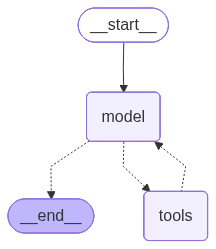

In [7]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# Agent 에서 사용할 모든 Tool 목록 정의
all_tools = [
    record_warranty_status,   # 보증 상태 기록 Tool
    record_issue_type,        # 문제 유형 기록 Tool
    provide_solution,         # 해결 방안 제공 Tool
    escalate_to_human,        # 사람 상담원 연결 Tool
]

# Agent 생성
agent = create_agent(
    model,
    tools=all_tools,
    # Agent 실행 중 상태를 구조적으로 관리하기 위한 타입 정의
    state_schema=SupportState,
    # --------------------------------------------------------
    # Middleware 설정
    # --------------------------------------------------------
    # apply_step_config:
    #   - 현재 단계 확인
    #   - 시스템 프롬프트 변경
    #   - Tool 사용 제한
    middleware=[apply_step_config],
    checkpointer=InMemorySaver(),
)

agent

## 7. 멀티 턴 대화 실행

여러 턴에 걸쳐 상태 전환을 확인합니다.

In [8]:
from langchain_core.messages import HumanMessage
import uuid  # 고유 ID 생성을 위한 모듈

# 스레드 ID 생성
#   → Agent 대화 세션 식별자
#   → Checkpointer 가 상태를 저장할 때 사용됨
#   → 같은 thread_id 를 사용하면 이전 상태가 이어짐
thread_id = str(uuid.uuid4())

config = {"configurable": {"thread_id": thread_id}}

print("=" * 80)
print("턴 1: 보증 확인 - warranty_collector 단계에서 시작")
print("=" * 80)

# Agent 실행
result = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="안녕하세요, 제 휴대폰 화면이 깨졌어요."
            )
        ]
    },
    config=config
)

# Agent 응답 메시지 출력
for msg in result["messages"]:
    # pretty_print 메서드가 있으면 보기 좋게 출력
    if hasattr(msg, 'pretty_print'):
        msg.pretty_print()
    else:
        print(msg)

# 현재 Workflow 단계 출력
# current_step:
#   → Agent 상태(State)에 저장된 현재 단계

print(f"\n현재 단계: {result.get('current_step', 'N/A')}")

턴 1: 보증 확인 - warranty_collector 단계에서 시작
================================ Human Message =================================

안녕하세요, 제 휴대폰 화면이 깨졌어요.
================================== Ai Message ==================================

안녕하세요! 화면이 깨져 불편하시겠어요 — 도와드리겠습니다. 먼저 이 기기가 아직 보증 기간 내에 있나요? (예 / 아니요)

현재 단계: N/A


### 턴 2: 보증 상태 응답

In [9]:
print("\n" + "=" * 80)
print("턴 2: 보증 상태 응답")
print("=" * 80)

result = agent.invoke(
    {"messages": [HumanMessage(content="네, 아직 보증 기간 내입니다.")]},
    config=config
)

for msg in result["messages"]:
    if hasattr(msg, 'pretty_print'):
        msg.pretty_print()
    else:
        print(msg)

print(f"\n현재 단계: {result.get('current_step', 'N/A')}")
print(f"보증 상태: {result.get('warranty_status', 'N/A')}")


턴 2: 보증 상태 응답
================================ Human Message =================================

안녕하세요, 제 휴대폰 화면이 깨졌어요.
================================== Ai Message ==================================

안녕하세요! 화면이 깨져 불편하시겠어요 — 도와드리겠습니다. 먼저 이 기기가 아직 보증 기간 내에 있나요? (예 / 아니요)
================================ Human Message =================================

네, 아직 보증 기간 내입니다.
================================== Ai Message ==================================
Tool Calls:
  record_warranty_status (call_eQo5Muax1QCJSePIJUiSJnUk)
 Call ID: call_eQo5Muax1QCJSePIJUiSJnUk
  Args:
    status: in_warranty
================================= Tool Message =================================
Name: record_warranty_status

Warranty status recorded as: in_warranty
================================== Ai Message ==================================
Tool Calls:
  record_issue_type (call_S5eKBrpYBcuRQgwlS2yJ5E1K)
 Call ID: call_S5eKBrpYBcuRQgwlS2yJ5E1K
  Args:
    issue_type: hardware
================================= To

### 턴 3: 이슈 설명

In [10]:
print("\n" + "=" * 80)
print("턴 3: 이슈 설명")
print("=" * 80)

result = agent.invoke(
    {"messages": [HumanMessage(content="화면이 물리적으로 깨졌어요. 떨어뜨려서 그런 것 같아요.")]},
    config=config
)

for msg in result["messages"]:
    if hasattr(msg, 'pretty_print'):
        msg.pretty_print()
    else:
        print(msg)

print(f"\n현재 단계: {result.get('current_step', 'N/A')}")
print(f"이슈 유형: {result.get('issue_type', 'N/A')}")


턴 3: 이슈 설명
================================ Human Message =================================

안녕하세요, 제 휴대폰 화면이 깨졌어요.
================================== Ai Message ==================================

안녕하세요! 화면이 깨져 불편하시겠어요 — 도와드리겠습니다. 먼저 이 기기가 아직 보증 기간 내에 있나요? (예 / 아니요)
================================ Human Message =================================

네, 아직 보증 기간 내입니다.
================================== Ai Message ==================================
Tool Calls:
  record_warranty_status (call_eQo5Muax1QCJSePIJUiSJnUk)
 Call ID: call_eQo5Muax1QCJSePIJUiSJnUk
  Args:
    status: in_warranty
================================= Tool Message =================================
Name: record_warranty_status

Warranty status recorded as: in_warranty
================================== Ai Message ==================================
Tool Calls:
  record_issue_type (call_S5eKBrpYBcuRQgwlS2yJ5E1K)
 Call ID: call_S5eKBrpYBcuRQgwlS2yJ5E1K
  Args:
    issue_type: hardware
================================= Tool 

### 턴 4: 해결책 제공

In [11]:
print("\n" + "=" * 80)
print("턴 4: 해결책 제공")
print("=" * 80)

result = agent.invoke(
    {"messages": [HumanMessage(content="어떻게 해야 하나요?")]},
    config=config
)

for msg in result["messages"]:
    if hasattr(msg, 'pretty_print'):
        msg.pretty_print()
    else:
        print(msg)

print(f"\n현재 단계: {result.get('current_step', 'N/A')}")


턴 4: 해결책 제공
================================ Human Message =================================

안녕하세요, 제 휴대폰 화면이 깨졌어요.
================================== Ai Message ==================================

안녕하세요! 화면이 깨져 불편하시겠어요 — 도와드리겠습니다. 먼저 이 기기가 아직 보증 기간 내에 있나요? (예 / 아니요)
================================ Human Message =================================

네, 아직 보증 기간 내입니다.
================================== Ai Message ==================================
Tool Calls:
  record_warranty_status (call_eQo5Muax1QCJSePIJUiSJnUk)
 Call ID: call_eQo5Muax1QCJSePIJUiSJnUk
  Args:
    status: in_warranty
================================= Tool Message =================================
Name: record_warranty_status

Warranty status recorded as: in_warranty
================================== Ai Message ==================================
Tool Calls:
  record_issue_type (call_S5eKBrpYBcuRQgwlS2yJ5E1K)
 Call ID: call_S5eKBrpYBcuRQgwlS2yJ5E1K
  Args:
    issue_type: hardware
================================= Tool

## 8. 보증 기간 만료 시나리오

보증 기간이 만료된 경우의 워크플로우를 테스트합니다.

In [12]:
# 새로운 스레드로 보증 기간 만료 시나리오
thread_id2 = str(uuid.uuid4())
config2 = {"configurable": {"thread_id": thread_id2}}

print("=" * 80)
print("보증 기간 만료 시나리오:")
print("=" * 80)

# 턴 1
result = agent.invoke(
    {"messages": [HumanMessage(content="제품에 문제가 있어요.")]},
    config=config2
)

# 턴 2: 보증 기간 만료
result = agent.invoke(
    {"messages": [HumanMessage(content="아니요, 보증 기간이 지났어요.")]},
    config=config2
)

print(f"보증 상태: {result.get('warranty_status', 'N/A')}")

# 턴 3: 하드웨어 문제
result = agent.invoke(
    {"messages": [HumanMessage(content="하드웨어 문제예요. 배터리가 부풀어 올랐어요.")]},
    config=config2
)

print(f"이슈 유형: {result.get('issue_type', 'N/A')}")

# 턴 4: 해결책 (에스컬레이션 예상)
result = agent.invoke(
    {"messages": [HumanMessage(content="어떻게 해야 하나요?")]},
    config=config2
)

for msg in result["messages"]:
    if hasattr(msg, 'pretty_print'):
        msg.pretty_print()
    else:
        print(msg)

보증 기간 만료 시나리오:
보증 상태: out_of_warranty
이슈 유형: hardware
================================ Human Message =================================

제품에 문제가 있어요.
================================== Ai Message ==================================

안녕하세요! 도와드리겠습니다. 사용 중인 기기가 아직 보증 기간 내에 있나요? 예 또는 아니오로 알려주세요.
================================ Human Message =================================

아니요, 보증 기간이 지났어요.
================================== Ai Message ==================================
Tool Calls:
  record_warranty_status (call_4kZEcc813V1PWLd4K3CKjWyZ)
 Call ID: call_4kZEcc813V1PWLd4K3CKjWyZ
  Args:
    status: out_of_warranty
================================= Tool Message =================================
Name: record_warranty_status

Warranty status recorded as: out_of_warranty
================================== Ai Message ==================================

확인했습니다 — 보증 기간이 지난 상태로 기록되어 있습니다. 문제 분류를 진행하려면 먼저 증상을 자세히 알려주세요. 다음 항목에 답해 주시면 하드웨어 문제인지 소프트웨어 문제인지 판단하는 데 도움이 됩니다.

1) 증상(무슨 일이 발생하나요?): 예: 전원이

## 실습문제: 보증 기간 내 + 소프트웨어 문제 시나리오

본문에서 다루지 않은 **보증 기간 내 + 소프트웨어 문제** 시나리오를 직접 실행해 보세요.

1. 새 `thread_id`와 `config`를 만들어 새로운 대화 세션을 시작하세요.
2. 멀티 턴 대화로 워크플로우를 진행하세요.
   - 턴 1: 문제 호소 (예: "휴대폰 앱이 자꾸 강제 종료돼요")
   - 턴 2: 보증 기간 내라고 응답
   - 턴 3: 소프트웨어 문제라고 설명
   - 턴 4: 해결책 요청
3. 각 턴이 끝날 때마다 `current_step`, `warranty_status`, `issue_type`을 출력해 상태 전환을 확인하고, 마지막 턴에서 `escalate_to_human`이 아니라 `provide_solution` 도구가 호출되는지 확인하세요.
